# RatioTap demo — the shipping converter, measured

Family convention: this notebook drives the **actual shipping C++** through
the C ABI (`tools/capi/`, ctypes bridge `ratiotap_py.py`, which builds
`build_capi/` on first import) — nothing here is a Python re-implementation.
It demonstrates the three things RatioTap promises: exact rational
conversion, deterministic accounting, and the economy profile's measured
spectral contract.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ratiotap_py import RatioConverter, version

print("RatioTap", ".".join(map(str, version())))
for direction in ("down", "up"):
    for profile in ("economy", "transparent"):
        c = RatioConverter(direction=direction, profile=profile)
        fs_in = 48000.0 if direction == "down" else 44100.0
        print(f"{direction:5s} {profile:12s} taps={c.taps:3d} "
              f"latency={c.latency_input_frames:5.1f} smp = "
              f"{c.latency_input_frames / fs_in * 1e3:.2f} ms")


RatioTap 0.1.0
down  economy      taps= 78 latency= 39.0 smp = 0.81 ms
down  transparent  taps=184 latency= 92.0 smp = 1.92 ms
up    economy      taps= 44 latency= 22.0 smp = 0.50 ms
up    transparent  taps= 96 latency= 48.0 smp = 1.09 ms


## Exact accounting

`frames_needed` / `outputs_for` are exact arithmetic, not estimates: a
steady-state superblock of 147 outputs costs exactly 160 inputs (the fresh
start costs one less — the pre-advance convention the cell below
demonstrates), and feeding the converter in arbitrary ragged chunks produces
exactly the predicted totals. This is the
capability the asynchronous engine can never offer, and what the Bluetooth
bridge composition (examples/bluetooth_bridge.cpp) sits on.


In [2]:
rng = np.random.default_rng(1)
c = RatioConverter(direction="down", profile="economy")
# Pre-advance convention: from the fresh zero-primed state the first 147
# outputs cost 159 inputs — the 160th is the down-payment on the NEXT
# superblock's first output. Steady state costs exactly M=160 per L=147:
print("fresh:  frames_needed(147) =", c.frames_needed(147))
print("        frames_needed(294) - frames_needed(147) =",
      c.frames_needed(294) - c.frames_needed(147), " (steady superblock: exactly 160)")
assert c.frames_needed(294) - c.frames_needed(147) == 160

x = rng.standard_normal(48000).astype(np.float32) * 0.5
predicted = int(c.outputs_for(len(x)))
made = 0
pos = 0
while pos < len(x):                       # ragged chunks, 1..997 frames
    n = int(rng.integers(1, 998))
    made += len(c.process(x[pos:pos + n]))
    pos += n
print(f"predicted outputs: {predicted}, produced: {made}")
assert made == predicted
c.reset()


fresh:  frames_needed(147) = 159
        frames_needed(294) - frames_needed(147) = 160  (steady superblock: exactly 160)
predicted outputs: 44100, produced: 44100


## The economy contract, measured on the shipping engine

A 3-tone program (997 Hz, 6 kHz, 18.5 kHz) plus a deliberately hostile
23 kHz ultrasonic component, converted 48 → 44.1 through the C ABI. The
acceptance criteria from PLAN §8: every spurious product at least the
stopband (71 dB) below its source; decimation aliases confined above
20 kHz by arithmetic; the imaging products (e.g. the 23 kHz tone's image at
25 kHz folding to 19.1 kHz) bounded by the stopband.


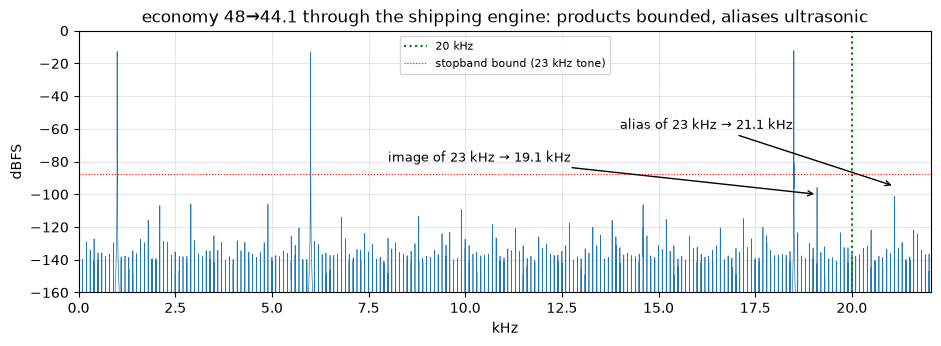

worst audible-band product:  -95.9 dBFS


In [3]:
fs_in, fs_out = 48000.0, 44100.0
n_in = 1 << 17
t = np.arange(n_in) / fs_in
tones = [(997.0, 0.25), (6000.0, 0.25), (18500.0, 0.25), (23000.0, 0.15)]
x = sum(a * np.sin(2 * np.pi * f * t) for f, a in tones).astype(np.float32)

c = RatioConverter(direction="down", profile="economy")
y = np.concatenate([c.process(x), c.flush()])
skip = int(c.latency_input_frames) * 2
y = y[skip:]

win = np.blackman(len(y))
spec = 20 * np.log10(np.maximum(np.abs(np.fft.rfft(y * win)) / (win.sum() / 2), 1e-12))
f = np.fft.rfftfreq(len(y), 1 / fs_out)

plt.figure(figsize=(11, 3.4))
plt.plot(f / 1e3, spec, lw=0.5)
plt.axvline(20, color='g', ls=':', label='20 kHz')
plt.axhline(-16.5 - 71, color='r', ls=':', lw=0.8, label='stopband bound (23 kHz tone)')
plt.annotate('alias of 23 kHz → 21.1 kHz', xy=(21.1, -95), xytext=(14, -60),
             arrowprops=dict(arrowstyle='->'), fontsize=9)
plt.annotate('image of 23 kHz → 19.1 kHz', xy=(19.1, -100), xytext=(8, -80),
             arrowprops=dict(arrowstyle='->'), fontsize=9)
plt.ylim(-160, 0); plt.xlim(0, 22.05)
plt.xlabel('kHz'); plt.ylabel('dBFS'); plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.title('economy 48→44.1 through the shipping engine: products bounded, aliases ultrasonic')
plt.show()

# The numeric contract, asserted:
tone_mask = np.zeros(len(f), bool)
for f0, _ in tones[:3]:
    tone_mask |= np.abs(f - f0) < 80
audible = ~tone_mask & (f > 200) & (f < 20000)
print(f"worst audible-band product: {spec[audible].max():6.1f} dBFS")
assert spec[audible].max() < -16.5 - 71 + 6  # 23 kHz tone at -16.5 dBFS, stopband 71 dB, window grace


## Measured passband response

Sine probes through the shipping engine (fit amplitude per frequency): flat
to the 19 kHz economy passband edge within the design's ±0.003 dB, rolling
into the transition exactly where the design says.


   100 Hz    +0.002 dB
  1000 Hz    -0.000 dB
  5000 Hz    +0.000 dB
 10000 Hz    +0.000 dB
 15000 Hz    +0.000 dB
 17000 Hz    +0.000 dB
 18000 Hz    +0.000 dB
 19000 Hz    +0.002 dB
 19800 Hz    -0.658 dB
 20500 Hz    -5.694 dB
 21200 Hz   -20.999 dB


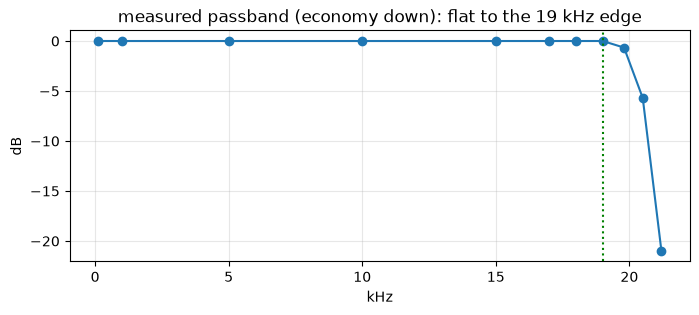

In [4]:
def measured_gain_db(freq_hz):
    c = RatioConverter(direction="down", profile="economy")
    n = 1 << 15
    x = (0.5 * np.sin(2 * np.pi * freq_hz / fs_in * np.arange(n))).astype(np.float32)
    y = c.process(x)[int(c.latency_input_frames) * 2:]
    w = 2 * np.pi * freq_hz / fs_out
    i = np.arange(len(y))
    a = 2 / len(y) * np.abs(np.sum(y * np.exp(-1j * w * i)))
    return 20 * np.log10(a / 0.5)

freqs = [100, 1000, 5000, 10000, 15000, 17000, 18000, 19000, 19800, 20500, 21200]
gains = [measured_gain_db(fq) for fq in freqs]
for fq, g in zip(freqs, gains):
    print(f"{fq:6d} Hz  {g:+8.3f} dB")
assert all(abs(g) < 0.02 for fq, g in zip(freqs, gains) if fq <= 19000)

plt.figure(figsize=(8, 3))
plt.plot(np.array(freqs) / 1e3, gains, 'o-')
plt.axvline(19, color='g', ls=':'); plt.ylabel('dB'); plt.xlabel('kHz')
plt.title('measured passband (economy down): flat to the 19 kHz edge')
plt.grid(alpha=0.3); plt.show()


## Summary

- The shipping engine's accounting is exact under ragged streaming.
- The economy spectral contract holds on real converted program material:
  audible band bounded by the stopband, aliases confined above 20 kHz.
- The passband is flat to the design edge through the whole C ABI path.

The Bluetooth composition (RatioTap for the number, SampleRateTap for the
clock) is demonstrated by `examples/bluetooth_bridge.cpp`: +200 ppm crystal,
servo locks at +200.1 ppm, tone recovered at 997.000 Hz, 2.0 ms total
latency.
